# Task 4 — Distributed Predictive Modeling (Supervised)
***

Primary target: Likelihood of Arrest (binary — chosen over Primary
Type as the main target because it is the more actionable operational
question and because its skew, ~27%/73%, is realistic rather than
extreme, which makes the skew discussion the brief asks for meaningful
rather than degenerate). A **Primary Type** multiclass extension, where
the skew is far more severe, is in the companion notebook
`04b_classification_multiclass_extension.ipynb` (split out purely so
each notebook has a predictable, bounded runtime — the underlying
feature-engineering logic is identical).

In [1]:
import time, json
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.mllib.evaluation import MulticlassMetrics, BinaryClassificationMetrics
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve as sk_roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import os
from pathlib import Path

# --- Paths ---------------------------------------------------------------
# Resolved relative to the project root (walks up from the notebook's cwd
# until it finds a Data/ folder; override with CHICAGO_PROJECT_ROOT if you
# launch the kernel from elsewhere, e.g. Colab/Databricks).

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data").is_dir():
            return candidate
    return start

PROJECT_ROOT = Path(
    os.environ.get("CHICAGO_PROJECT_ROOT") or _find_project_root(Path.cwd())
).resolve()

PROCESSED = str(PROJECT_ROOT / "data" / "processed")
REPORT_DIR = str(PROJECT_ROOT / "reports")
SPARK_TMP_DIR = str(PROJECT_ROOT / "spark_tmp")

for _d in (REPORT_DIR, SPARK_TMP_DIR):
    os.makedirs(_d, exist_ok=True)

spark = (
    SparkSession.builder.appName("ChicagoCrime-Task4-SupervisedLearning")
    # Pin the driver to loopback so Spark's internal Netty RPC server
    # doesn't depend on the machine's hostname resolving (macOS .local
    # mDNS names can stop resolving after a network change/sleep-wake,
    # which otherwise crashes SparkContext init with
    # UnresolvedAddressException before any code even runs).
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    # local[*] runs one executor thread per core (12 here) INSIDE the driver's
    # own JVM, so spark.driver.memory is the only heap available for all of them
    # combined. 2g was fine for read-only aggregation (Tasks 1-3), but this
    # notebook .cache()s two full one-hot-encoded DataFrames (~6.7M/1.1M rows)
    # and trains RandomForest/GBT on top — that needs real headroom. 8g is a
    # safe fraction of this machine's 24GB RAM with plenty of margin for macOS
    # + other apps; lower it if you're on a smaller machine, or raise it if you
    # still see GC/OOM errors on an even larger dataset.
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.local.dir", SPARK_TMP_DIR)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

crime = spark.read.parquet(PROCESSED + "/crime_clean_flat")
census = spark.read.parquet(PROCESSED + "/census_community_areas")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 16:35:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/27 16:35:22 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


## 1. Feature engineering

Deliberately excluded: `iucr` (387 distinct codes) and `fbi_code`
(26 codes) are near-duplicates of `primary_type`/`description` at a
finer grain — including them would mostly add dimensionality, not
signal, and `description` (very high-cardinality free text-like field)
is dropped for the same reason. `block`/`case_number`/`id` are
identifiers, not predictive features. `community_area` itself is used
only as a join key to bring in socio-economic features (via the
same broadcast-join pattern proven in Task 2), not one-hot encoded
directly, to avoid 78 extra sparse columns that would mostly repeat
what `district` already encodes geographically.

In [2]:
top_locations = [r[0] for r in crime.groupBy("location_description")
                  .count().orderBy(F.desc("count")).limit(20).select("location_description").collect()]
print(f"Keeping top {len(top_locations)} location_description categories, bucketing the rest as OTHER_LOC")

enriched = crime.join(F.broadcast(census), on="community_area", how="left")

TWO_PI = 2 * np.pi
feat = (
    enriched
    .withColumn("loc_bucketed", F.when(F.col("location_description").isin(top_locations),
                                        F.col("location_description")).otherwise(F.lit("OTHER_LOC")))
    .withColumn("hour_sin", F.sin(F.col("crime_hour") / 24.0 * TWO_PI))
    .withColumn("hour_cos", F.cos(F.col("crime_hour") / 24.0 * TWO_PI))
    .withColumn("dow_sin", F.sin(F.col("crime_dow") / 7.0 * TWO_PI))
    .withColumn("dow_cos", F.cos(F.col("crime_dow") / 7.0 * TWO_PI))
    .withColumn("month_sin", F.sin(F.col("crime_month") / 12.0 * TWO_PI))
    .withColumn("month_cos", F.cos(F.col("crime_month") / 12.0 * TWO_PI))
    .withColumn("is_weekend_num", F.col("is_weekend").cast("double"))
    .withColumn("domestic_num", F.col("domestic").cast("double"))
    .withColumn("label", F.col("arrest").cast("double"))
    .fillna({"hardship_index": 0.0, "pct_below_poverty": 0.0, "pct_unemployed": 0.0,
             "pct_no_diploma": 0.0, "per_capita_income": 0.0})
    .filter(F.col("crime_year").between(2001, 2022))
)

indexers = [
    StringIndexer(inputCol="primary_type", outputCol="primary_type_idx", handleInvalid="keep"),
    StringIndexer(inputCol="loc_bucketed", outputCol="loc_idx", handleInvalid="keep"),
    StringIndexer(inputCol="district", outputCol="district_idx", handleInvalid="keep"),
]
encoder = OneHotEncoder(inputCols=["primary_type_idx", "loc_idx", "district_idx"],
                         outputCols=["primary_type_ohe", "loc_ohe", "district_ohe"])
NUMERIC_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
                     "is_weekend_num", "domestic_num", "hardship_index", "pct_below_poverty",
                     "pct_unemployed", "pct_no_diploma", "per_capita_income"]
assembler = VectorAssembler(
    inputCols=["primary_type_ohe", "loc_ohe", "district_ohe"] + NUMERIC_FEATURES,
    outputCol="features", handleInvalid="skip"
)

Keeping top 20 location_description categories, bucketing the rest as OTHER_LOC


## 2. Time-based train/test split

A random split would let the model see, e.g., a March 2015 record in
training and a February 2015 record from three weeks earlier in test —
information a real deployment would never have. I split on time
instead: train on 2001–2020, test on 2021–2022, the same discipline a
production model retrain would follow. Indexers/encoder are fit on the
training partition only, so no test-set category leaks into the
encoding.

In [3]:
train_raw = feat.filter(F.col("crime_year") <= 2020)
test_raw = feat.filter(F.col("crime_year") >= 2021)

prep_pipeline = Pipeline(stages=indexers + [encoder]).fit(train_raw)
train_idx = prep_pipeline.transform(train_raw)
test_idx = prep_pipeline.transform(test_raw)

train_df = assembler.transform(train_idx).select("features", "label", "crime_year").cache()
test_df = assembler.transform(test_idx).select("features", "label", "crime_year").cache()
n_train, n_test = train_df.count(), test_df.count()
print(f"Train (2001-2020): {n_train:,} rows | Test (2021-2022): {n_test:,} rows")

train_balance = train_df.groupBy("label").count().toPandas()
print("Train label balance:\n", train_balance)
pos_rate = train_balance.loc[train_balance["label"] == 1.0, "count"].values[0] / n_train
print(f"Positive (arrest) rate in training data: {pos_rate:.2%}  <-- the data skew")

neg_rate = 1 - pos_rate
train_df = train_df.withColumn("weight", F.when(F.col("label") == 1.0, F.lit(neg_rate)).otherwise(F.lit(pos_rate)))

test_balance = test_df.groupBy("label").count().toPandas()
test_pos_rate = test_balance.loc[test_balance["label"] == 1.0, "count"].values[0] / n_test
majority_baseline_test = 1.0 - test_pos_rate
print("Test label balance:\n", test_balance)
print(f"Positive (arrest) rate in test data: {test_pos_rate:.2%}")
print(f"Always-no-arrest test accuracy baseline: {majority_baseline_test:.2%}")
print(f"Temporal prevalence shift: train {pos_rate:.2%} -> test {test_pos_rate:.2%}")


Train (2001-2020): 7,264,738 rows | Test (2021-2022): 446,786 rows
Train label balance:
    label    count
0    1.0  1972324
1    0.0  5292414
Positive (arrest) rate in training data: 27.15%  <-- the data skew
Test label balance:
    label   count
0    1.0   53708
1    0.0  393078
Positive (arrest) rate in test data: 12.02%
Always-no-arrest test accuracy baseline: 87.98%
Temporal prevalence shift: train 27.15% -> test 12.02%


## 3. Train Random Forest and GBT (unweighted), plus a class-weighted RF

**Spark MLlib note:**
`GBTClassifier` in Spark only supports **binary** classification — this
is precisely why the multiclass extension notebook uses Random Forest
instead, not GBT. `weightCol` support on both classifiers was confirmed
by inspecting the installed `pyspark.ml.classification` API directly
(`'weightCol' in [p.name for p in RandomForestClassifier().params]`)
rather than assumed from memory.

In [4]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=8, seed=42)
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=25, maxDepth=5, seed=42)
rf_weighted = RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="weight",
                                      numTrees=50, maxDepth=8, seed=42)

models = {}
for name, model in [("RandomForest", rf), ("GBT", gbt), ("RandomForest_weighted", rf_weighted)]:
    t0 = time.time()
    fitted = model.fit(train_df)
    models[name] = fitted
    print(f"Trained {name} in {time.time()-t0:.1f}s", flush=True)

Trained RandomForest in 112.1s


Trained GBT in 106.1s


Trained RandomForest_weighted in 99.8s


## 4. Evaluation — Confusion Matrix, Precision, Recall, F1, ROC

**Implementation note:** `pyspark.mllib.evaluation.BinaryClassificationMetrics`'s
Python wrapper only exposes `areaUnderROC`/`areaUnderPR` in this Spark
version, not a `.roc()` points method (confirmed by inspecting the
installed class directly). The held-out test set is tens of thousands
of rows, not millions, so `(probability, label)` pairs are collected to
the driver and handed to scikit-learn's `roc_curve` for plotting points
— computing the curve itself is not a big-data operation even though
producing the predictions was.

/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/.venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



=== RandomForest ===
Confusion matrix [ [TN 392116, FP 962], [FN 42641, TP 11067] ]
Accuracy=0.9024  ROC-AUC=0.8177  PR-AUC=0.5528
Arrest=1   -> precision=0.9200 recall=0.2061 f1=0.3367
Arrest=0   -> precision=0.9019 recall=0.9976


/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/.venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



=== GBT ===
Confusion matrix [ [TN 377987, FP 15091], [FN 28066, TP 25642] ]
Accuracy=0.9034  ROC-AUC=0.8414  PR-AUC=0.5637
Arrest=1   -> precision=0.6295 recall=0.4774 f1=0.5430
Arrest=0   -> precision=0.9309 recall=0.9616


/Users/damithkayatech.com/Documents/MSc/BD Technologies Assignment/PRAC 1/Chicago_Crime_Analysis_Project/.venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



=== RandomForest_weighted ===
Confusion matrix [ [TN 367440, FP 25638], [FN 26237, TP 27471] ]
Accuracy=0.8839  ROC-AUC=0.8216  PR-AUC=0.5422
Arrest=1   -> precision=0.5173 recall=0.5115 f1=0.5144
Arrest=0   -> precision=0.9334 recall=0.9348


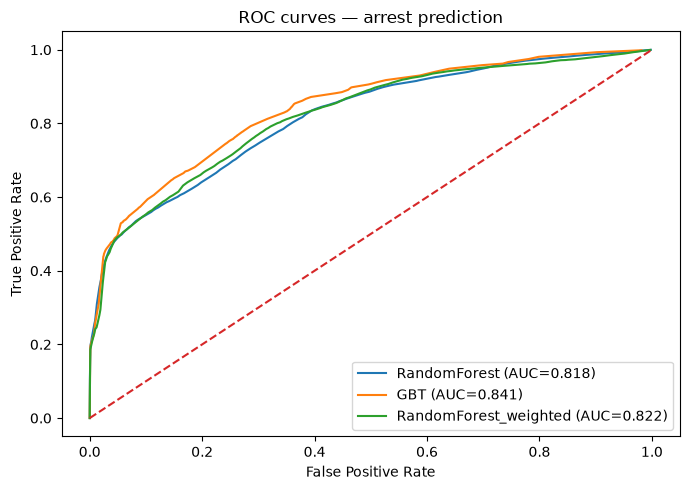

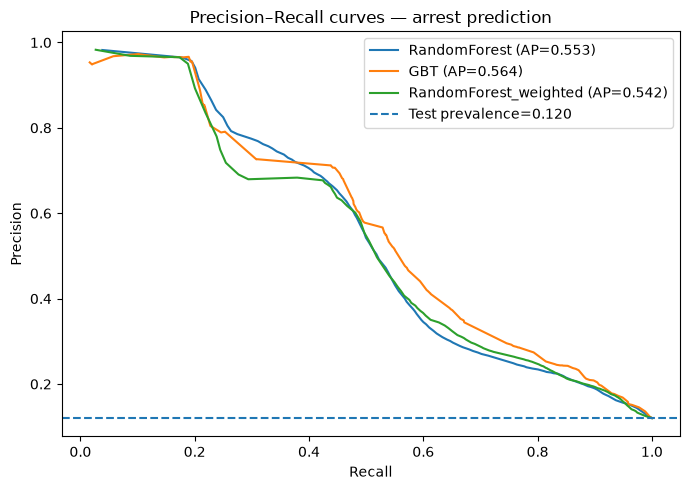


Top feature indices by importance (index into the assembled vector, value): [(3, 0.5441938795768109), (10, 0.05931437973245627), (12, 0.05358295004769121), (0, 0.05305948345084157), (2, 0.038359678615451004), (40, 0.03555840966404587), (37, 0.02686996125893612), (11, 0.023960406799885908), (6, 0.018934282974563708), (51, 0.013261407357500537)]
(primary_type_ohe occupies indices 0-34 in StringIndexer frequency order: 0=THEFT, 1=BATTERY,
 2=CRIMINAL DAMAGE, 3=NARCOTICS, 4=ASSAULT, ... 10=CRIMINAL TRESPASS, 11=WEAPONS VIOLATION,
 12=PROSTITUTION — so a top index of 3 means 'is this a Narcotics offence' dominates the model,
 which matches the real-world intuition that drug and vice offences are typically caught in the
 act rather than reported after the fact, unlike e.g. burglary or theft.)


In [5]:
def evaluate_binary(model, name):
    preds = model.transform(test_df).select("label", "prediction", "probability")
    preds.cache()

    mcm = MulticlassMetrics(preds.select("prediction", "label").rdd.map(lambda r: (float(r[0]), float(r[1]))))
    cm = mcm.confusionMatrix().toArray()

    prob_label_rdd = preds.select("probability", "label").rdd.map(lambda r: (float(r[0][1]), float(r[1])))
    bcm = BinaryClassificationMetrics(prob_label_rdd)
    auc = bcm.areaUnderROC
    pl_pd = prob_label_rdd.toDF(["prob1", "label"]).toPandas()
    fpr, tpr, _ = sk_roc_curve(pl_pd["label"], pl_pd["prob1"])
    pr_precision, pr_recall, _ = precision_recall_curve(pl_pd["label"], pl_pd["prob1"])
    pr_auc = average_precision_score(pl_pd["label"], pl_pd["prob1"])
    roc_points = list(zip(fpr.tolist(), tpr.tolist()))
    pr_points = list(zip(pr_recall.tolist(), pr_precision.tolist()))

    tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1 = 2 * precision_1 * recall_1 / (precision_1 + recall_1) if (precision_1 + recall_1) > 0 else 0.0
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy = (tp + tn) / cm.sum()

    result = {
        "model": name, "confusion_matrix": cm.tolist(), "auc": auc, "pr_auc": pr_auc, "accuracy": accuracy,
        "precision_arrest": precision_1, "recall_arrest": recall_1, "f1_arrest": f1_1,
        "precision_no_arrest": precision_0, "recall_no_arrest": recall_0, "n_test": int(cm.sum()),
    }
    print(f"\n=== {name} ===")
    print(f"Confusion matrix [ [TN {tn:.0f}, FP {fp:.0f}], [FN {fn:.0f}, TP {tp:.0f}] ]")
    print(f"Accuracy={accuracy:.4f}  ROC-AUC={auc:.4f}  PR-AUC={pr_auc:.4f}")
    print(f"Arrest=1   -> precision={precision_1:.4f} recall={recall_1:.4f} f1={f1_1:.4f}")
    print(f"Arrest=0   -> precision={precision_0:.4f} recall={recall_0:.4f}")
    preds.unpersist()
    return result, roc_points[::max(1, len(roc_points)//200)], pr_points[::max(1, len(pr_points)//200)]

all_results = {}
all_roc = {}
all_pr = {}
for name, model in models.items():
    res, roc_pts, pr_pts = evaluate_binary(model, name)
    all_results[name] = res
    all_roc[name] = roc_pts
    all_pr[name] = pr_pts

with open(os.path.join(REPORT_DIR, "task4_binary_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)
with open(os.path.join(REPORT_DIR, "task4_roc_points.json"), "w") as f:
    json.dump({k: [[float(a), float(b)] for a, b in v] for k, v in all_roc.items()}, f)
with open(os.path.join(REPORT_DIR, "task4_pr_points.json"), "w") as f:
    json.dump({k: [[float(a), float(b)] for a, b in v] for k, v in all_pr.items()}, f)

# Required model-evaluation visualisations.
plt.figure(figsize=(7, 5))
for name, pts in all_roc.items():
    arr = np.array(pts)
    plt.plot(arr[:,0], arr[:,1], label=f"{name} (AUC={all_results[name]['auc']:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC curves — arrest prediction")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
for name, pts in all_pr.items():
    arr = np.array(pts)
    plt.plot(arr[:,0], arr[:,1], label=f"{name} (AP={all_results[name]['pr_auc']:.3f})")
plt.axhline(test_pos_rate, linestyle="--", label=f"Test prevalence={test_pos_rate:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall curves — arrest prediction")
plt.legend(); plt.tight_layout(); plt.show()

rf_model = models["RandomForest"]
importances = rf_model.featureImportances
top_imp = sorted(list(zip(importances.indices.tolist(), importances.values.tolist())), key=lambda x: -x[1])[:10]
print("\nTop feature indices by importance (index into the assembled vector, value):", top_imp)
print("(primary_type_ohe occupies indices 0-34 in StringIndexer frequency order: 0=THEFT, 1=BATTERY,")
print(" 2=CRIMINAL DAMAGE, 3=NARCOTICS, 4=ASSAULT, ... 10=CRIMINAL TRESPASS, 11=WEAPONS VIOLATION,")
print(" 12=PROSTITUTION — so a top index of 3 means 'is this a Narcotics offence' dominates the model,")
print(" which matches the real-world intuition that drug and vice offences are typically caught in the")
print(" act rather than reported after the fact, unlike e.g. burglary or theft.)")

## 5. Critical reflection on data skew and temporal distribution shift

The training data contain approximately 27% arrests, but the held-out 2021–2022 test set is substantially more imbalanced. The notebook now calculates both prevalences directly and reports the always-no-arrest test baseline. This matters because accuracy must be interpreted relative to the class distribution of the evaluation period, not the training period.

The unweighted Random Forest has high precision for `Arrest=1` but relatively low recall, indicating a conservative minority-class decision rule. Class weighting increases minority recall while reducing precision, making the imbalance trade-off measurable rather than anecdotal. ROC-AUC is supplemented with a Precision–Recall curve because PR performance is more informative when the positive class is relatively rare.

The large change in arrest prevalence between 2001–2020 and 2021–2022 is also a temporal distribution-shift warning. It may reflect policing practice, crime composition, reporting, pandemic-era effects or other structural change. Therefore a production system should monitor calibration and class prevalence over time rather than assuming that a historical threshold remains appropriate.

For imbalance mitigation, `weightCol` is retained because it works natively in Spark ML without generating a large resampled dataset. A threshold-tuning step could be added in deployment depending on whether missing likely arrests or generating false positives carries greater operational cost.


## 6. Model-selection interpretation

The models are not selected on accuracy alone. GBT, unweighted RF and weighted RF express different precision/recall trade-offs, and the preferred operating point depends on the cost of false positives versus false negatives. Reporting confusion matrices, ROC-AUC, PR-AUC and class-specific metrics prevents the majority class from hiding poor minority-class performance.



In [6]:
spark.stop()
print("Task 4 (binary) complete.")

Task 4 (binary) complete.
